# Analyse des Betriebsverhaltens einer Strömungsmaschine
In diesem Notebook erfolgt die Auswertung der realen Messdaten einer industriellen Wasserpumpe. Zunächst werden die benötigten Bibliotheken importiert und die Herstellerdaten für das verbaute Laufrad mit einem Durchmesser von **269 mm** hinterlegt. Mithilfe einer kubischen Interpolation wird eine stetige Funktion für das Pumpenkennfeld erstellt, um für jeden gemessenen Volumenstrom die exakte Förderhöhe und den Wirkungsgrad berechnen zu können.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 1. Pumpen-Daten aus dem Hersteller-Datenblatt (269 mm Laufrad)
# ---------------------------------------------------------
# Stützpunkte aus dem Kennfeld
Q_points = np.array([0, 100, 200, 300, 400, 500, 600]) # Volumenstrom in m³/h
H_points = np.array([25.0, 24.5, 23.0, 21.0, 18.0, 14.0, 8.0]) # Förderhöhe in m
eta_points = np.array([0.01, 40.0, 65.0, 78.0, 83.0, 78.0, 60.0]) / 100.0 # Wirkungsgrad

# Interpolations-Funktionen zur stetigen Berechnung
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta = interp1d(Q_points, eta_points, kind='cubic', fill_value='extrapolate')

## Datenaufbereitung und Glättung
Die Sensordaten werden aus der bereitgestellten CSV-Datei geladen. Um die Daten zu glätten  wird zusätzlich ein gleitender Mittelwert berechnet um den tatsächlichen Betriebstrend in den anschließenden Visualisierungen besser darzustellen.

In [18]:
# ---------------------------------------------------------
# 2. Messdaten einlesen & aufbereiten
# ---------------------------------------------------------
filename = '/content/sample_data/volume_flow_data.csv'
df = pd.read_csv(filename)
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe und Wirkungsgrad berechnen
df['H_m'] = f_H(df[col_flow])

# Begrenzung des Wirkungsgrads auf minimal 1%, um eine Division durch Null zu vermeiden
df['eta'] = np.clip(f_eta(df[col_flow]), 0.01, 1.0)

# Glättung des Volumenstroms (15-Minuten-Fenster) zur Trendanalyse
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

## Physikalische und wirtschaftliche Berechnung
Die Berechnung der hydraulischen Leistung erfolgt anhand der Gleichung $P_{hyd} = \rho \cdot g \cdot Q \cdot H$.
Anschließend wird der Energieverbrauch in kWh über das Messintervall ($\Delta t$ = 1 Minute) ermittelt und in tatsächliche Nutzenergie sowie Verlustenergie unterteilt. Zur Quantifizierung der Anlagenineffizienz wird eine wirtschaftliche Betrachtung mit einem angenommenen Industriestrompreis von 0,15 € / kWh durchgeführt.

In [19]:
# ---------------------------------------------------------
# 3. Physikalische & Wirtschaftliche Berechnungen
# ---------------------------------------------------------
rho = 1000 # Dichte von Wasser (kg/m³)
g = 9.81   # Erdbeschleunigung (m/s²)

# Hydraulische Leistung (Umrechnung von m³/h in m³/s)
df['P_hyd_W'] = rho * g * (df[col_flow] / 3600) * df['H_m']

# Elektrische Leistung (Input)
df['P_el_W'] = df['P_hyd_W'] / df['eta']

# Energieberechnung in kWh (Messintervall 1 Minute = 1/60 h)
delta_t_h = 1 / 60
df['E_hyd_kWh'] = (df['P_hyd_W'] / 1000) * delta_t_h
df['E_el_kWh'] = (df['P_el_W'] / 1000) * delta_t_h
df['E_loss_kWh'] = df['E_el_kWh'] - df['E_hyd_kWh']

# Stromkosten-Raten für die Visualisierung berechnen (Annahme: 0,15 € / kWh)
strompreis = 0.15
df['Cost_Rate_hyd'] = (df['P_hyd_W'] / 1000) * strompreis
df['Cost_Rate_loss'] = ((df['P_el_W'] - df['P_hyd_W']) / 1000) * strompreis

# Geglättete Werte für Leistung und Kosten für die spätere Darstellung erzeugen
df['P_el_smooth'] = df['P_el_W'].rolling(window=15, min_periods=1).mean()
df['P_hyd_smooth'] = df['P_hyd_W'].rolling(window=15, min_periods=1).mean()
df['Cost_hyd_smooth'] = df['Cost_Rate_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_smooth'] = df['Cost_Rate_loss'].rolling(window=15, min_periods=1).mean()

## Ergebnisse
Ergebnisse berechnen und ausgeben.

In [20]:
# ---------------------------------------------------------
# 4. Numerische Ausgabe der Gesamtwerte
# ---------------------------------------------------------
total_el_kWh = df['E_el_kWh'].sum()
total_hyd_kWh = df['E_hyd_kWh'].sum()
total_loss_kWh = df['E_loss_kWh'].sum()
avg_eff = (total_hyd_kWh / total_el_kWh) * 100

total_cost = total_el_kWh * strompreis
loss_cost = total_loss_kWh * strompreis

print("--- TECHNISCHE AUSWERTUNG (269 mm Laufrad) ---")
print(f"Gesamtverbrauch (elektrisch):   {total_el_kWh:.2f} kWh")
print(f"Verlustenergie (Wärme etc.):    {total_loss_kWh:.2f} kWh")
print(f"Durchschnittliche Effizienz:    {avg_eff:.2f} %")
print("\n--- WIRTSCHAFTLICHE AUSWERTUNG ---")
print(f"Gesamte Stromkosten:            {total_cost:.2f} €")
print(f"Kosten durch Ineffizienz:       {loss_cost:.2f} €")
print("----------------------------------------------")

--- TECHNISCHE AUSWERTUNG (269 mm Laufrad) ---
Gesamtverbrauch (elektrisch):   494.41 kWh
Verlustenergie (Wärme etc.):    144.81 kWh
Durchschnittliche Effizienz:    70.71 %

--- WIRTSCHAFTLICHE AUSWERTUNG ---
Gesamte Stromkosten:            74.16 €
Kosten durch Ineffizienz:       21.72 €
----------------------------------------------


## Visuelle Analyse des Betriebsverhaltens
Die nachfolgenden Diagramme veranschaulichen das  Verhalten der Anlage. Durch die Überlagerung der Sensordaten mit dem gleitenden Mittelwert wird der tatsächliche Betriebstrend hervorgehoben. Das H-Q-Kennfeld zeigt zudem die Verteilung der realen Betriebspunkte entlang der Herstellerkennlinie. Die betriebswirtschaftliche Auswertung erfolgt abschließend über ein Flächendiagramm der stündlichen Stromkosten.

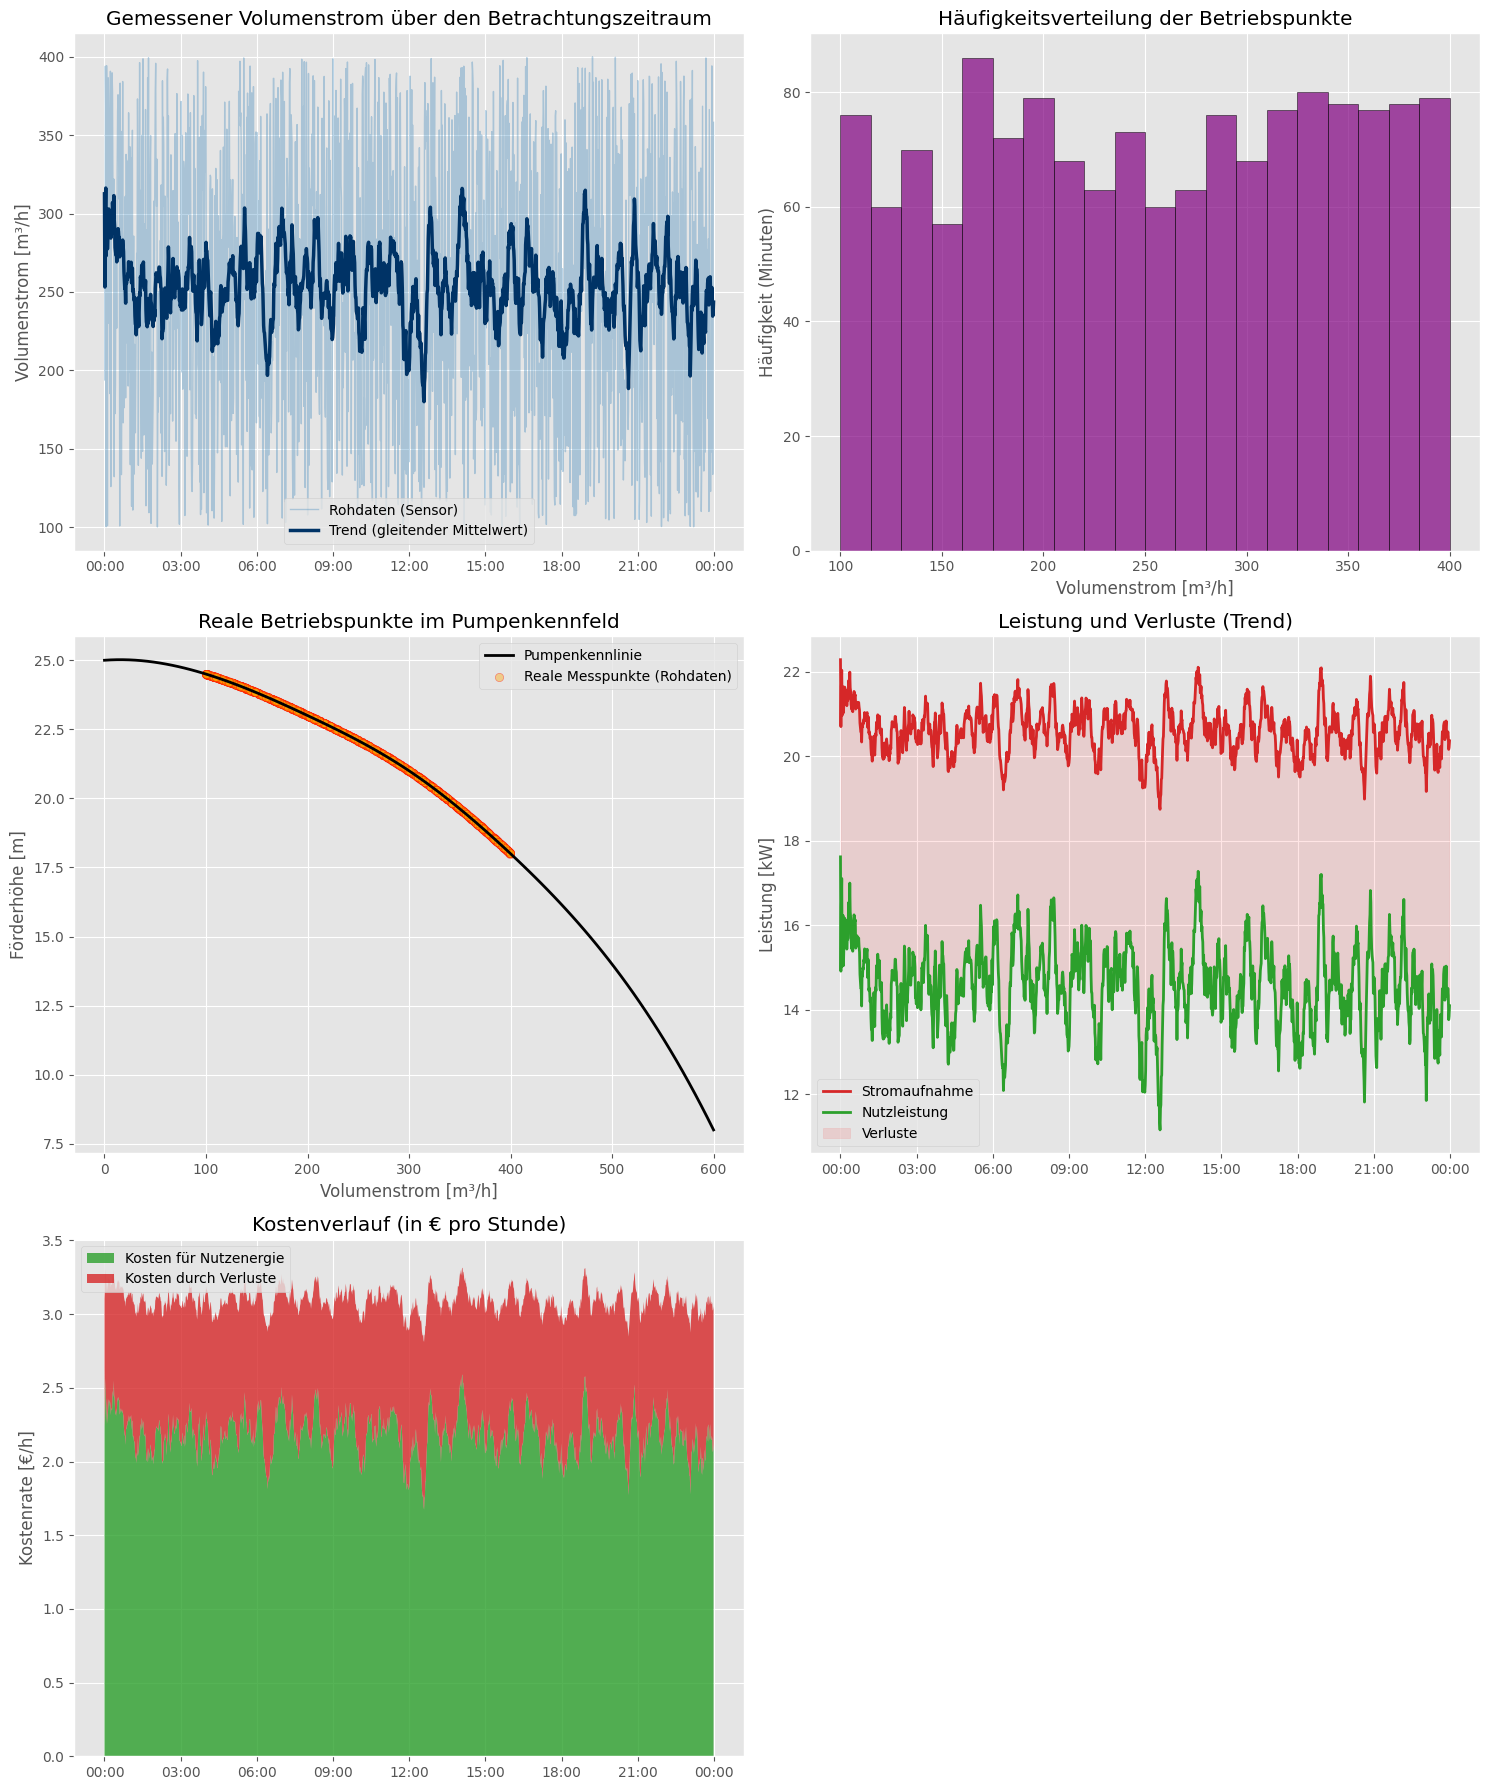

In [21]:
# ---------------------------------------------------------
# 5. Diagramme erstellen
# ---------------------------------------------------------
plt.style.use('ggplot')
fig, axs = plt.subplots(3, 2, figsize=(15, 18))

# Plot 1: Volumenstrom (Zeitverlauf)
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#1f77b4', alpha=0.3, linewidth=1, label='Rohdaten (Sensor)')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#003366', linewidth=2.5, label='Trend (gleitender Mittelwert)')
axs[0, 0].set_title('Gemessener Volumenstrom über den Betrachtungszeitraum')
axs[0, 0].set_ylabel('Volumenstrom [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()

# Plot 2: Histogramm
axs[0, 1].hist(df[col_flow], bins=20, color='purple', alpha=0.7, edgecolor='black')
axs[0, 1].set_title('Häufigkeitsverteilung der Betriebspunkte')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Häufigkeit (Minuten)')

# Plot 3: H-Q Kennfeld
Q_smooth_line = np.linspace(0, 600, 100)
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='black', linewidth=2, label='Pumpenkennlinie')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='orange', alpha=0.4, edgecolor='red', label='Reale Messpunkte (Rohdaten)')
axs[1, 0].set_title('Reale Betriebspunkte im Pumpenkennfeld')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()

# Plot 4: Leistungsvergleich (kW)
axs[1, 1].plot(df['Timestamp'], df['P_el_smooth']/1000, label='Stromaufnahme', color='#d62728', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['P_hyd_smooth']/1000, label='Nutzleistung', color='#2ca02c', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['P_hyd_smooth']/1000, df['P_el_smooth']/1000, color='red', alpha=0.1, label='Verluste')
axs[1, 1].set_title('Leistung und Verluste (Trend)')
axs[1, 1].set_ylabel('Leistung [kW]')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()

# Plot 5: Stromkosten (Stacked Area)
axs[2, 0].stackplot(df['Timestamp'], df['Cost_hyd_smooth'], df['Cost_loss_smooth'],
                    labels=['Kosten für Nutzenergie', 'Kosten durch Verluste'],
                    colors=['#2ca02c', '#d62728'], alpha=0.8)
axs[2, 0].set_title('Kostenverlauf (in € pro Stunde)')
axs[2, 0].set_ylabel('Kostenrate [€/h]')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')

# Sechstes (leeres) Diagrammfeld ausblenden
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()